# 1. How HMP works: practical, methodological and theoretical grounds

## Data 

### Simulation

We will start by simulating data to demonstrate the HMP analysis on simulated data.
First, we need to load several libraries, after which we simulate a dataset with 4 events and the resulting 5 inter-event times (stimulus -> event 1, event 1 -> event 2, ..., event 4 -> response.

> [!NOTE]
> Most of this code is specific to simulation cases, to apply to your own data, use the code of the next tutorials



In [1]:
## Importing these packages is specific for this simulation case
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gamma

## Importing HMP
import hmp
from hmp import simulations

In [2]:
cpus = 2 # For multiprocessing, usually a good idea to use multiple CPUs as long as you have enough RAM

n_trials = 100 #Number of trials to simulate
sfreq = 500 #Sampling rate of the simulated data

##### Here we define the sources of the brain activity (event) for each trial
n_events = 4 #How many events to simulate
frequency = 10. #Frequency of the event defining its duration, half-sine of 10Hz = 50ms
amplitudes = [2.5e-8, 2e-8, 2e-8, 3e-8, 0] #Amplitude of the event in nAm, defining signal to noise ratio, last is response event
shape = 2 #shape of the gamma distribution, with the defined means below it dictates the onset time probabilities
means = np.array([60, 150, 200, 100, 80])/shape #Mean duration of the between event times in ms
#Which source to activate for each event (see atlas when calling simulations.available_sources())
names = ['inferiortemporal-lh','caudalanteriorcingulate-rh','bankssts-lh','superiorparietal-lh','superiorparietal-lh']

sources = []
for source in zip(names, amplitudes, means): #One source = one frequency, one amplitude and a given by-trial variability distribution
    sources.append([source[0], frequency, source[1], gamma(shape, scale=source[2])])

# Function used to generate the data
files = simulations.simulate(sources, n_trials, cpus, 'dataset', overwrite=True, sfreq=sfreq, seed=0)
eeg_file = [files[0][0]]
event_file = files[0][1]
#load electrode position, specific to the simulations
info = simulations.positions()

Simulating 0_raw.fif
0_raw.fif simulated


Next, we load the simulated data, reflecting a realistic EEG dataset of a single participant. As you can see, we use standard MNE functions here.

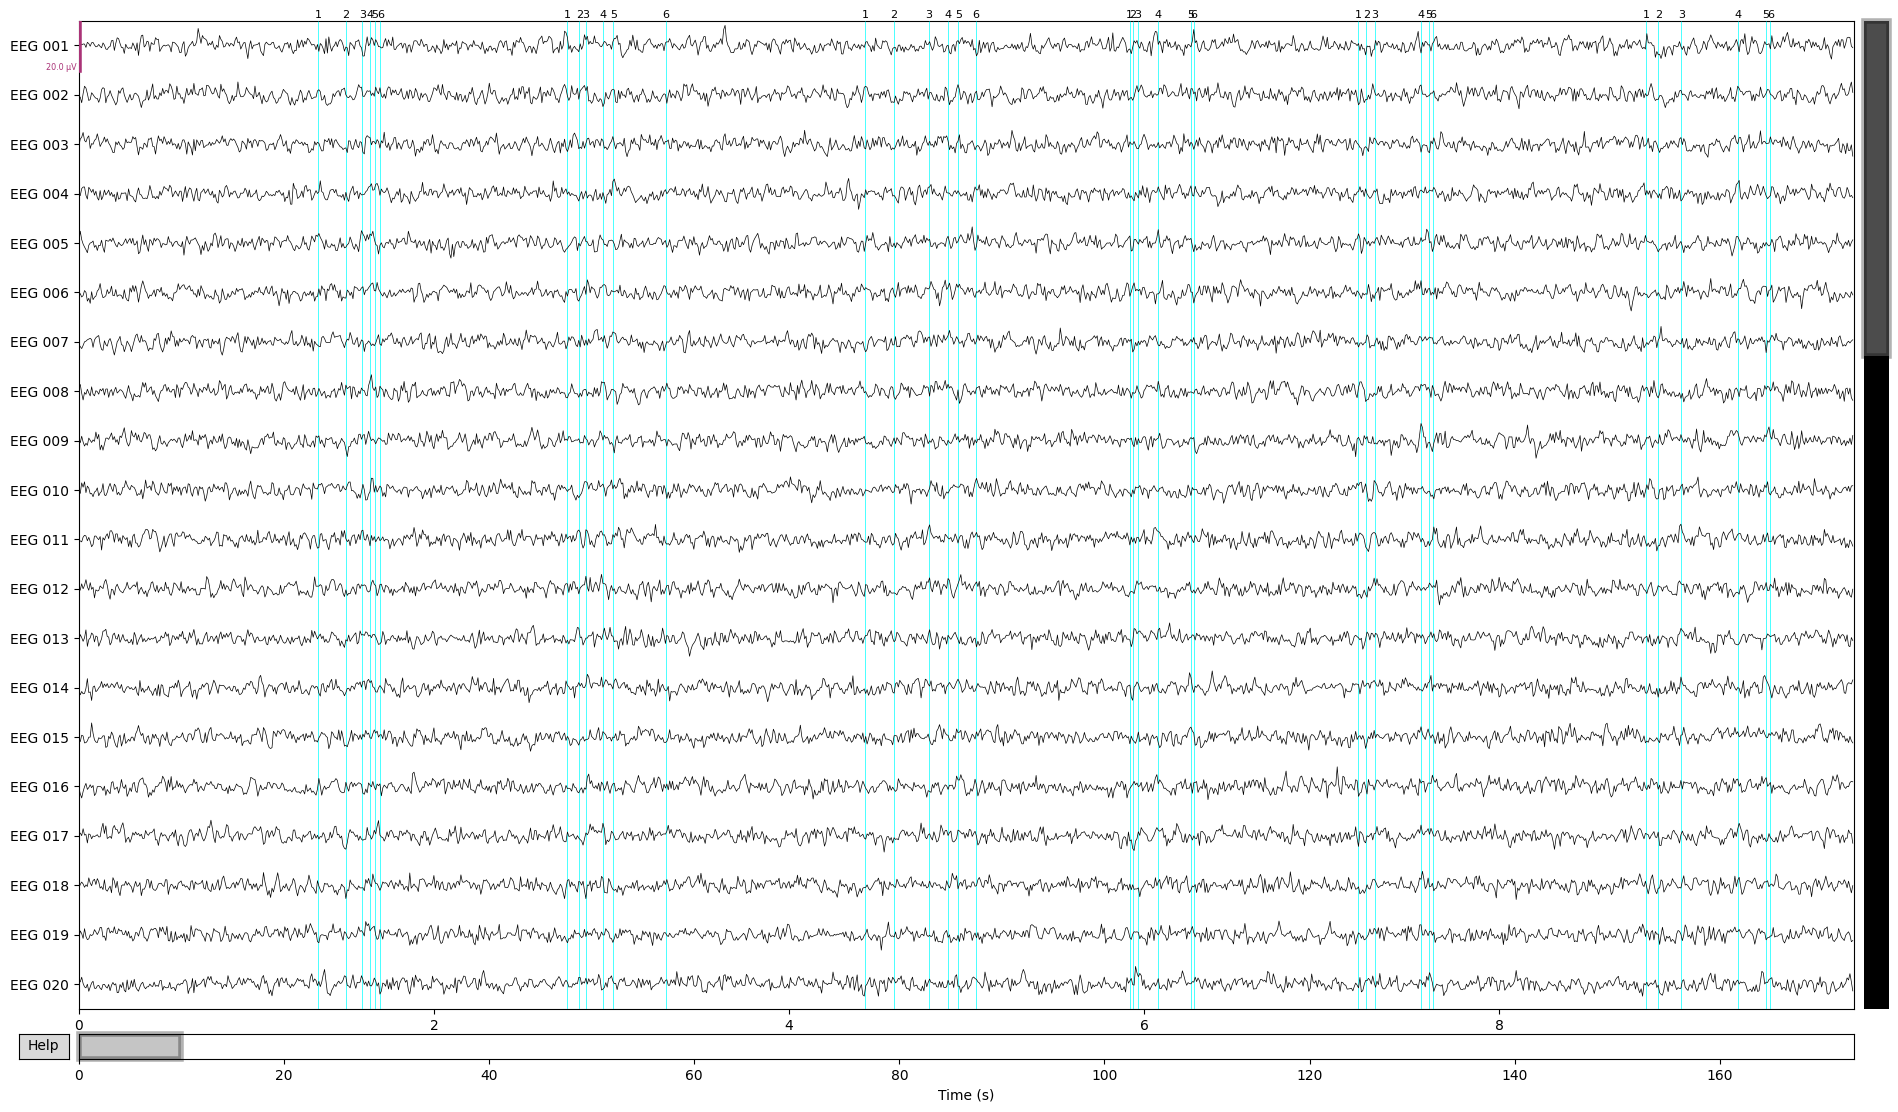

In [3]:
#Recovering the events to epoch the data (in the number of trials defined above)
events = np.load(event_file)
resp_trigger = int(np.max(np.unique(events[:,2])))#Resp trigger is the last source in each trial
event_id = {'stimulus/dummy':1}#trigger 1 = stimulus
resp_id = {'response/dummy':resp_trigger}
#Keeping only stimulus and response triggers

#Visualising the raw simulated EEG data
import mne

raw = mne.io.read_raw_fif(eeg_file[0], preload=False, verbose=False)
raw.pick_types(eeg=True).plot(scalings=dict(eeg=1e-5), events=events, block=True);


### Reading in data
We now prepare the data for the HMP package. First, we read the data into an xarray.

In [4]:
### Reading the data
from hmp import io

# Info on channel location
montage = simulations.sim_info().get_montage()

# Define some preprocessing arguments
preprocessing = dict(sfreq=sfreq, #Resampling the data at this sampling frequency
                     lowpass=40, # at which frequency we want to apply the lowpass filter
                     highpass=0.1, #Same for highpass
                     reference='average', #What reference shold the data be re-referenced to
                     pick_channels='eeg' #What channels do we want, can also be a list of channel names
                    )

# Define some epoching arguments
epoching = dict(
    tmin=-.2,# Time to keep before stim onset for baseline correction
    tmax=2#Up to when should we look for a duration end (e.g. response) event
    )

# Reading the data that is in raw .fif format (.bdf also supported by this function)
epoch_data, info = io.read_mne_raw(eeg_file,
                             centering_id=event_id,
                             event_id=resp_id, 
                             events_provided=[events],#Usually not necessary for real data
                             montage = montage,
                             preprocessing_kwargs=preprocessing,
                             epoching_kwargs=epoching
                            )
epoch_data

Processing dataset dataset
Opening raw data file /home/gabriel/ownCloud/projects/RUGUU/hmp/docs/source/notebooks/dataset_raw.fif...
    Read a total of 1 projection items:
        Average EEG reference (1 x 60) active
    Range : 0 ... 86535 =      0.000 ...   173.070 secs
Ready.
Reading 0 ... 86535  =      0.000 ...   173.070 secs...
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Removing existing average EEG reference projection.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutof

/home/gabriel/ownCloud/projects/RUGUU/hmp/hmp/io/utils.py:18: UserWarning: No 'baseline' provided, using default value of (None, 0) seconds 
use 'epoching_kwargs' to override default values
  warn(f"No '{key}' provided, using default value of {value} seconds \n"


Sampling frequency of the instance is already 500.0, returning unmodified.
Adding metadata with 5 columns
100 matching events found
Setting baseline interval to [-0.2, 0.0] s
Applying baseline correction (mode: mean)
Using data from preloaded Raw for 100 events and 1101 original time points ...
0 bad epochs dropped


<xarray.Dataset> Size: 26MB
Dimensions:        (recording: 1, epoch: 100, channel: 59, sample: 1101)
Coordinates:
  * recording      (recording) <U7 28B 'dataset'
    subject        (recording) <U7 28B 'dataset'
  * epoch          (epoch) int64 800B 0 1 2 3 4 5 6 7 ... 93 94 95 96 97 98 99
    event_name     (epoch) object 800B 'dummy' 'dummy' ... 'dummy' 'dummy'
    stimulus_time  (epoch) float64 800B 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    response_time  (epoch) float64 800B 0.35 0.554 0.624 ... 0.48 0.468 0.36
    stimulus       (epoch) object 800B 'dummy' 'dummy' ... 'dummy' 'dummy'
    response       (epoch) object 800B 'dummy' 'dummy' ... 'dummy' 'dummy'
  * channel        (channel) <U7 2kB 'EEG 001' 'EEG 002' ... 'EEG 059' 'EEG 060'
  * sample         (sample) int64 9kB -100 -99 -98 -97 -96 ... 997 998 999 1000
Data variables:
    data           (recording, epoch, channel, sample) float32 26MB -2.237e-0...
Attributes: (12/13)
    tmin:                  -0.2
    tmax:                  2
    baseline:              (None, 0)
    proj:                  False
    detrend:               None
    on_missing:            warn
    ...                    ...
    reject_by_annotation:  False
    sfreq:                 500.0
    lowpass:               40.0
    highpass:              0.10000000149011612
    reference:             average
    pick_channels:         eeg

The previous function epochs the data around our (simulated) stimuli and stores any additional infomation along (here 'stimulus'). The data is stored in an xarray; a handy way of using matrices with named dimensions and additional attributes.

For example, we can now easily draw an ERP of three channels:

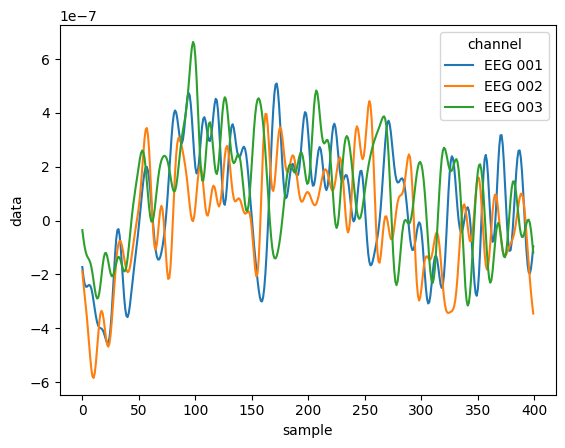

In [5]:
#example usage of xarray
epoch_data.sel(channel=['EEG 001','EEG 002','EEG 003'], sample=range(400))\
    .data.groupby('sample').mean(['recording','epoch']).plot.line(hue='channel')
plt.show()

### Data preparation for HMP

Next, we preprocess the data for HMP:
- We cut the data at the interval of interest (here the time between simulated stimuli and simulated response denoted as `response_time` in `epoch_data`)
- Apply PCA and select top components to lower computational load
- Whiten the variance of the components and standardize the variance of each trial.

For the PCA we select 3 components for simplicity (more on this with real data in Tutorial 3).

In [6]:
# Loading the data into the data format for HMP estimation
base_data = hmp.basedata.from_io(epoch_data)

# Crop the epochs to the duration of interest, here response_time
# The EEG signal on each trial will then be censored after the recorded response
base_data.crop_reject_epochs(
    duration_id='response_time',
    min_duration = 0, # We can also specify a minimum duration in seconds (e.g. anticipation)
    max_duration = np.inf, # Or a maximum duration (e.g. distraction or bug)
    offsets=0.03, # Adding 30ms before centering event and after duration end to pad for the crosscorrelation, not included in the data afterwards
    # And a threshold, i.e. reject trial if the absolute value of an electrode exceeds that value
    reject_amplitude = None #Here there are no such artifacts as we live in the safe world of simulations
)
# In this case the data is a perfect simulation so we can skip all these rejection steps, but see Tutorial 3 for real data

# Next we project the data into principal component space, again with simulated data
# that doesn't have much impact so we'll just select for illustration purposes:
base_data.project(hmp.projectors.PCA(n_comp=3))

# Then we whiten the components so that they are all at unit-variance
# Standardize the variance across epochs/trials so that each epoch contributes the same to the solution
# And we zscore each PC within each recording so that all recordings have the same contribution
base_data.apply_variance_ops(whiten=True, #All components have now unit variance
                            common_variance=True, # All trials have now the same standard deviation
                            recording_zscore=True, # Zscore the component per recording/participant, no effect as only one participant here
                            )

Found 100 trials with positively defined durations and 0 trials without durations (0 or nan)

Rejection summary: 
 0 trials rejected based on threshold of inf 
 0 trials rejected  based on duration limit of (0.002, inf) 
 0 with duration but without data (nan at time 0)


which turns the data into:

In [7]:
base_data

BaseData(data=<xarray.DataArray 'data' (sample: 666, component: 3, trial: 100)> Size: 799kB
array([[[ 0.31396922, -0.10595421,  0.4803691 , ...,  0.2971992 ,
          0.76311934, -0.24199246],
        [-0.58152366,  1.105235  ,  1.1131852 , ...,  0.22317389,
         -0.34559622,  0.03797136],
        [-0.17344262,  1.1803873 , -1.1462616 , ..., -0.42312834,
          0.49148232,  0.04711083]],

       [[ 0.10939641,  0.15713681,  0.40097305, ...,  0.37861174,
          0.5465866 , -0.39847338],
        [-0.7774601 ,  1.0424985 ,  0.8103482 , ...,  0.17113906,
         -0.4975842 ,  0.5219448 ],
        [-0.42949173,  1.0122725 , -1.1862868 , ..., -0.08343337,
          0.43694642, -0.16303799]],

       [[-0.02664471,  0.45576066,  0.33510092, ...,  0.4434581 ,
          0.3059802 , -0.5188336 ],
        [-0.94646823,  0.8567054 ,  0.50094277, ...,  0.11807276,
         -0.6063035 ,  1.1009697 ],
        [-0.6638329 ,  0.7575101 , -1.0511184 , ...,  0.33210525,
          0.39079905, 

The PCA has transformed the data into virtual channels (PCA components), so that each virtual channel combines contributions from all original channels. The contribution of each original channel to the, in this case three, components can be visualized as follows:

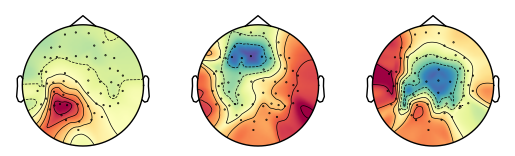

In [8]:
from hmp.visu import plot_components_sensor

plot_components_sensor(base_data.projector.weights, info)
plt.show()

The estimation performed by HMP will be done on these 3 virtual channels.

## HMP and implementation assumptions

### Expected pattern

HMP assumes that a transition or cognitive event is represented in the data as a specific pattern.
Therefore, before estimating an HMP model one needs to build such a pattern by defining its characteristics.

By default, HMP assumes a 50-ms half-sine, which can be created by invoking the `HalfSine` class. The class will then store the expected pattern with a 1000-Hz sampling frequency, which will be adjusted to the data later.

In [9]:
from hmp.patterns import HalfSine

event_halfsine = HalfSine()
event_halfsine

`event_halfsine.template` contains the shape that we expect to find in the data:

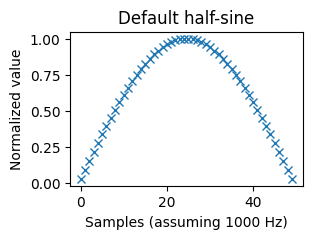

In [10]:
plt.figure(figsize=(3,2))
plt.plot(event_halfsine.template, 'x')
plt.ylabel('Normalized value')
plt.xlabel('Samples (assuming 1000 Hz)')
plt.title('Default half-sine')
plt.show()

However, you can also use any other shape if you have a specific hypothesis:

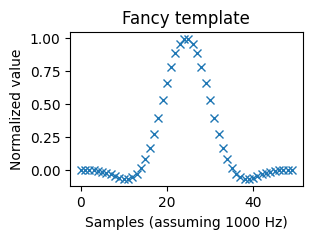

In [11]:
# Alternative template, just for fun
from scipy import signal

fancy = signal.windows.flattop(len(event_halfsine.template))
event_fancy = hmp.patterns.Pattern(template=fancy)

plt.figure(figsize=(3,2))
plt.plot(event_fancy.template, 'x')
plt.ylabel('Normalized value')
plt.xlabel('Samples (assuming 1000 Hz)')
plt.title('Fancy template')
plt.show()

We then create a `PatternData` object that combines the expected pattern with the data. This class will automatically cross-correlate the virtual channels in the data with the provided template.

Below, we plot those cross-correlated values for the first epoch; the vertical lines indicate the start of the events in the simulated data. As you can see, the cross-correlated values indicate the location of the events across channels.

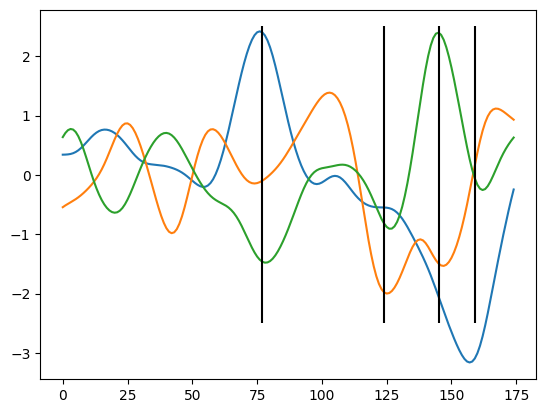

In [12]:
from hmp.patterndata import PatternData

pattern_data = PatternData.from_basedata(base_data, pattern=event_halfsine)
plt.plot(pattern_data.cross_corr[pattern_data.starts[0]:pattern_data.ends[0]])

#Recover the actual time of the simulated events
sim_source_times = np.reshape(np.ediff1d(events[:,0],to_begin=0)[events[:,2] > 1], (n_trials, n_events+1))
plt.vlines(sim_source_times[0,:-1].cumsum(), -2.5, 2.5, 'k') #overlaying the simulated event onset times
plt.show()

The specific pattern to be expected is an open discussion. Given the transient and oscillatory nature of E/MEG signals, a half-sine is a good starting point and is what we have used in the past. The specific width of the half-sine is very important (see [paper](https://direct.mit.edu/imag/article/doi/10.1162/imag_a_00400/125469/Trial-by-trial-detection-of-cognitive-events-in)); overall, shorter patterns capture both short and longer real events, up to the point were high frequency noise gets in the way of the estimation. 

Based on experience, a pattern width between 30 and 50 ms generally provides the most robust solutions. However, make sure the sampling frequency of your data is high enough, with 100 Hz data and a 30 ms half-sine pattern, your template would only consist of 3 samples. We recommend to use at least 5 samples for a template.

### Expected time distribution

In addition to the shape of the events, HMP also assumes the time between events to follow a specific time distribution. By default, HMP expects the times between event peaks to vary per-trial according to a Gamma distribution with a shape of 2 and a scale free to vary.

In [13]:
from hmp.distributions import Gamma

gamma_2 = Gamma()
gamma_2

For example, an event happening on average 100 ms following stimulus onset would have the blue distribution below (a Gamma distributions with a shape of 2 and a scale of 50). Alternatively, we could use a different distribution, for example a Weibull, visualized in orange.

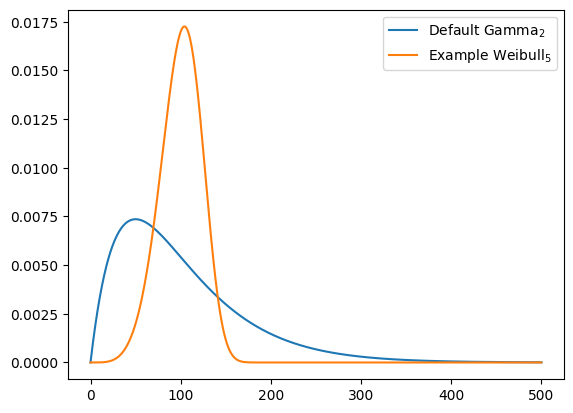

In [14]:
example_mean = 100
x = np.linspace(0, 500, 1000)
plt.plot(x, gamma_2.pdf(x, gamma_2.shape,
        scale=gamma_2.mean_to_scale(example_mean)),
        label=r'Default Gamma$_2$')

## Other distribution to illustrate
from hmp.distributions import Weibull

other_time_distribution = Weibull(shape=5)
plt.plot(x, other_time_distribution.pdf(x, other_time_distribution.shape,
        scale=other_time_distribution.mean_to_scale(example_mean)),
        label=r'Example Weibull$_5$')
plt.legend()
plt.show()

Overall the specific distribution has relatively little effect on the estimation (see [paper](https://direct.mit.edu/imag/article/doi/10.1162/imag_a_00400/125469/Trial-by-trial-detection-of-cognitive-events-in)). The most important thing is to not exclude likely times (e.g. the Weibull doesn't allow event to happen directly after the stimulus, for example).

> [!NOTE]
> Declaring a time distribution is not a requirement, if you don't provide one, HMP will assume a Gamma distribution with a shape of 2 and a scale free to vary. This is the default setting and works well in most cases.

## A first HMP model

### HMP parameters

After having defined the expected event pattern, cross-correlated it with the `base_data` data to from `pattern_data`, and defined the overall shape of the by-trial time distributions we can create a proper HMP model. In the remainder of this tutorial we'll use the `EventModel` class, which is a model with a pre-defined number of events that forms the basis for all more complex model classes (more on the different model classes in the next tutorial).

Given an expected number of events, such an `EventModel` will estimate the parameters of the time distribution between events and the contribution of each virtual channel to each event. Here we define such a model and fit it with 4 events; which we know is the true number of events given the simulated data.

In [15]:
from hmp.models import EventModel

model = EventModel(n_events = n_events)
model.fit(pattern_data, verbose=False) # fits with going through EM, illustrates the default starting points

As we used simulated data, we know the ground truth in this case: the time of each simulated event and the channels were associated with the events. The following cell extracts those true parameters:

In [16]:
# `events` refers to the actual simulation times of the events, specific to simulations only
sim_source_times, true_time_pars, true_channel_pars, _ = \
        simulations.simulated_times_and_parameters(events, model, pattern_data)

#### Time parameters

The `time_pars` attribute of an HMP model contains the time parameter of the choosen distribution for each event. The matrix below is a 2D array where each row corresponds to an event and each column corresponds to a parameter of the time distribution (in this case the Gamma distribution). The first column is the shape parameter (which is fixed) and the second column is the scale parameter (which is updated when we estimate an HMP model).

In [17]:
model.time_pars

array([[[ 2.        , 14.52138519],
        [ 2.        , 35.92053986],
        [ 2.        , 49.23881912],
        [ 2.        , 24.19652557],
        [ 2.        , 18.52272797]]])

We can compare these to the ground truth, which are indeed similar.

In [18]:
true_time_pars

array([[ 2, 15],
       [ 2, 35],
       [ 2, 51],
       [ 2, 21],
       [ 2, 18]])

We can then compare the Gamma distributions:

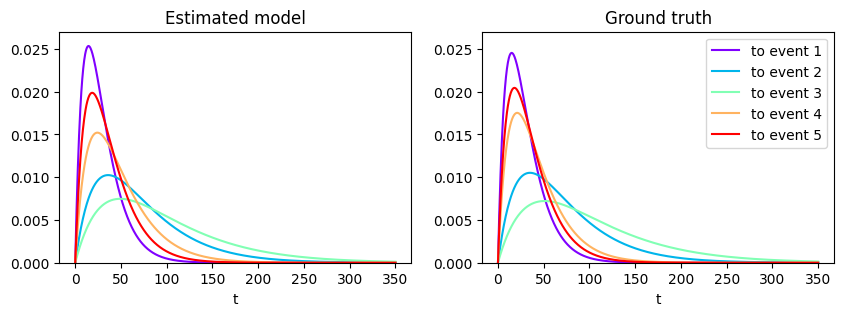

In [19]:
fig, axs = plt.subplots(1, 2,figsize=(10, 3))
colors = plt.cm.rainbow(np.linspace(0, 1, 5))

T = 350

#plot model
for event in range(5):
    axs[0].plot(np.linspace(0, T, 1001),
             gamma_2.pdf(np.linspace(0, T, 1001), gamma_2.shape, scale=model.time_pars[0, event, 1]),
             label=f'to event {event+1}', color=colors[event])
axs[0].set_xlabel('t')
axs[0].set_title('Estimated model')
axs[0].set_ylim(0,.027)

#plot ground truth
for event in range(5):
    axs[1].plot(np.linspace(0, T, 1001),
             gamma_2.pdf(np.linspace(0, T, 1001), gamma_2.shape, scale=true_time_pars[event, 1]),
             label=f'to event {event+1}', color=colors[event])
axs[1].set_xlabel('t')
axs[1].set_title('Ground truth')
axs[1].set_ylim(0,.027)

plt.legend()
plt.show()

The width of these distribution indicates the variability of the between-event durations over trials and (with real data) participants. Here they are clearly highly similar.

#### Channel parameters

The `channel_pars` attribute of an HMP model contains the contribution of each virtual channel (principal component) to each event. The matrix below is a 2D array where each row corresponds to an event and each column corresponds to a channel.

In [20]:
model.channel_pars

array([[[ 2.3115315 , -0.51829815, -1.3906808 ],
        [-0.18821998, -2.1090474 , -0.39271015],
        [-1.0747756 , -0.6901012 ,  1.3715456 ],
        [-3.0724158 ,  0.49114978, -1.8114363 ]]], dtype=float32)

Also here we can compare to the ground truth:

In [21]:
true_channel_pars

array([[ 2.5110483 , -0.6008211 , -1.4901168 ],
       [-0.27284253, -2.602355  , -0.5107018 ],
       [-1.8145621 , -0.9858608 ,  1.5874    ],
       [-3.1983907 ,  0.49923256, -1.8800001 ]], dtype=float32)

Visually, it's easier to make the comparison and see the correspondence:

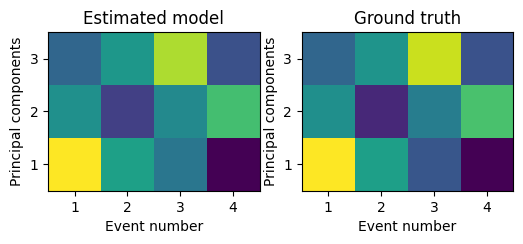

In [22]:
fig, axs = plt.subplots(1, 2,figsize=(6, 5))

#model
axs[0].imshow(model.channel_pars[0].T, origin="lower", vmax=2)
axs[0].set_ylabel('Principal components')
axs[0].set_xlabel('Event number')
axs[0].set_yticks(np.arange(pattern_data.cross_corr.shape[-1]), np.arange(pattern_data.cross_corr.shape[-1])+1)
axs[0].set_xticks(np.arange(n_events), np.arange(n_events)+1)
axs[0].set_title('Estimated model')

#ground truth
axs[1].imshow(true_channel_pars.T, origin="lower", vmax=2)
axs[1].set_ylabel('Principal components')
axs[1].set_xlabel('Event number')
axs[1].set_yticks(np.arange(pattern_data.cross_corr.shape[-1]), np.arange(pattern_data.cross_corr.shape[-1])+1)
axs[1].set_xticks(np.arange(n_events), np.arange(n_events)+1)
axs[1].set_title('Ground truth')

plt.show()

We used 3 PC components (y-axis) to estimate 4 events. As is visible in the matrix above, each event has a unique combination of component contributions, although this is not a requirement.

### Transforming the data to event probability space using these parameters

After fitting a model, we can `transform` data given the estimated parameters. Typically, one would use the same data the model has been fitted on, but that is not a requirement. The `transform` method returns the probability associated with each event for each E/MEG sample – so for every trial in the data.

In [23]:
# Transforming to event probability space
loglikelihood, estimates = model.transform(pattern_data)

We can now look at the probabilities associated with this true model

In [24]:
estimates

<xarray.DataArray (trial: 100, sample: 636, event: 4)> Size: 2MB
array([[[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [1.10110163e-03, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [1.92176679e-03, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        ...,
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

       [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [3.93423579e-05, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [6.04080196e-05, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        ...,
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

       [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [1.44893653e-04, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [3.16595222e-04, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        ...,
...
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

       [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [8.94279437e-05, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [3.93516879e-04, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        ...,
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

       [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [6.93656766e-05, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [2.61152774e-04, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        ...,
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00]]],
      shape=(100, 636, 4))
Coordinates:
  * trial          (trial) object 800B MultiIndex
    event_name     (trial) object 800B 'dummy' 'dummy' ... 'dummy' 'dummy'
    stimulus_time  (trial) float64 800B 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    response_time  (trial) float64 800B 0.35 0.554 0.624 ... 0.48 0.468 0.36
    stimulus       (trial) object 800B 'dummy' 'dummy' ... 'dummy' 'dummy'
    response       (trial) object 800B 'dummy' 'dummy' ... 'dummy' 'dummy'
    subject        (trial) <U7 3kB 'dataset' 'dataset' ... 'dataset' 'dataset'
  * recording      (trial) <U7 3kB 'dataset' 'dataset' ... 'dataset' 'dataset'
  * epoch          (trial) int64 800B 0 1 2 3 4 5 6 7 ... 93 94 95 96 97 98 99
    group          (trial) int8 100B 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0
  * sample         (sample) int64 5kB 0 1 2 3 4 5 6 ... 630 631 632 633 634 635
  * event          (event) int64 32B 0 1 2 3
Attributes:
    sfreq:         500.0
    event_width:   25
    likelihood:    134.72041
    group_lkh:     [134.72041]
    group_labels:  ('group all', array([['']], dtype=object))

This is a matrix with dimensions trial x sample_in_trial x event, where the values indicate the probablity of that event occurring at that sample.

We can represent this graphically, for example by plotting the average probability for each event at each time sample:

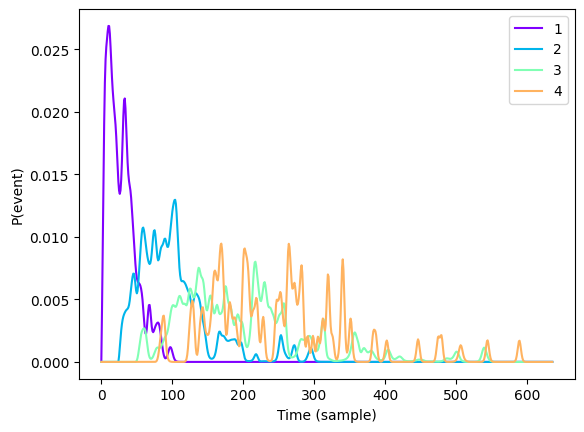

In [25]:
for event in range(n_events):
    plt.plot(estimates.sel(event=event).mean('trial'), label=event+1,
            color=colors[event])
plt.ylabel('P(event)')
plt.xlabel('Time (sample)')
plt.legend()
plt.show()

And we can even look at a single trial:

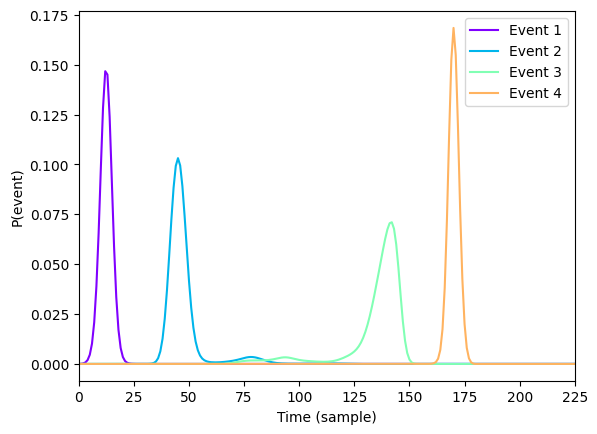

In [26]:
for event in range(n_events):
    plt.plot(estimates.isel(trial=-1, event=event), label=f"Event {event+1}",
            color=colors[event])
plt.ylabel('P(event)')
plt.xlabel('Time (sample)')
plt.xlim(0,225)
plt.legend()
plt.show()

#### Visualizing the average time location and topographies associated with the estimated events

While the plots above might not be the most intuitive, they do summarize the results of fitting an HMP model. However, the first thing we typically do is averaging the electrodes values at each most likely time point of each event, and then plot the topographies associated with these times in the original EEG space. This gives us a nice overview of the average event position and the topographies associated with each event, and is easier for us to interpret.

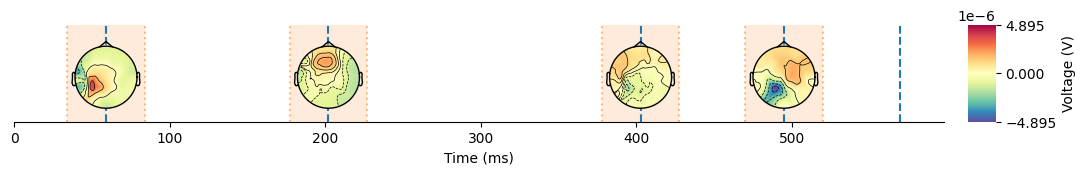

In [27]:
# Visualize the average event position and the topographies assocaited with each event
hmp.visu.plot_topo_timecourse(epoch_data, estimates, info)
plt.show()

## Estimating a model - details

in real data, to estimate this unkown set of parameters (time and channel parameters) we use the expectation maximization algorithm on the event probability as obtained through the Baum-Welsh algorithm. 
We start with neutral guess on the time and channel parameters (0's for `channel_pars`, and mean RT / (n_events + 1) for the `time_pars`). Here we combine fitting and transforming the data in one call, giving the same result as we saw above:

Estimating 4 events model


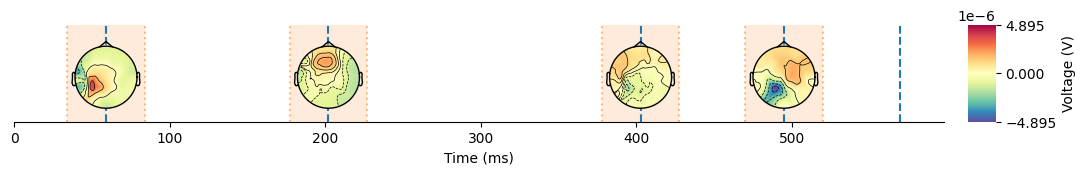

In [28]:
model = hmp.models.EventModel(n_events=n_events)
loglikelihood, estimates = model.fit_transform(pattern_data)
hmp.visu.plot_topo_timecourse(epoch_data, estimates, info)
plt.show()

### EM algorithm

Under the hood, HMP uses an expectation maximization algorithm to find the solution that best explains the data. The way it works is:
1. Make a first proposal on the time location and channel contribution towards each event
2. Compute the most likely location of the events given this proposition
3. Update the parameters according to this most likely position
4. Repeat steps 2-3 up to the moment where the loglikelihood of the data stops increasing more than the tolerance criterion (default 1e-4)

More details about the algorithm can be found in the accompanying 2024 [paper](https://direct.mit.edu/imag/article/doi/10.1162/imag_a_00400/125469/Trial-by-trial-detection-of-cognitive-events-in)

We can inspect the traces of this EM algorithm to see how the log-likelihood of the fit developed with iterations. This shows how many iterations it needed and at what Log-likelihood (LL) it stopped according to the default tolerance on the increase in LL (default 1e-4).

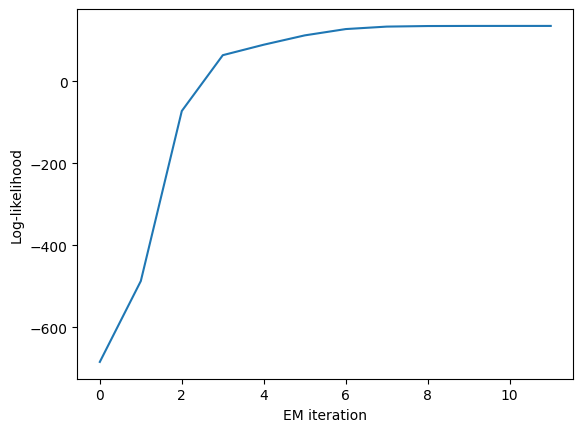

In [29]:
plt.plot(model.traces)
plt.ylabel('Log-likelihood')
plt.xlabel('EM iteration')
plt.show()

Along this we can take a look at how the position of the events were updated, i.e. how the time parameters changed according to the evolution of the EM algorithm:

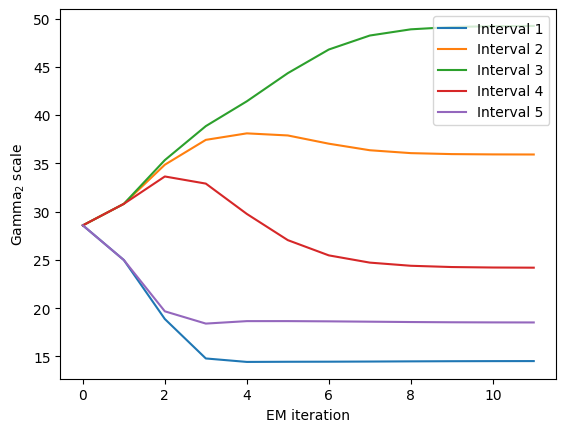

In [30]:
plt.plot(model.time_pars_dev[:,0,:,1], label=['Interval '+str(x) for x in [1,2,3,4,5]])
plt.ylabel(r'Gamma$_2$ scale')
plt.xlabel('EM iteration')
plt.legend(loc=1)
plt.show()

Here we see that the the first EM iteration starts with the assumption that all events are equally spaced in the RT. Then for example the first interval progressively became shorter while the second one became longer. As we progress in the EM iteration the time distribution parameters get more stable. We can increase the tolerance but this, most of the time, wouldn't have much consequences except making the fit slower: 

Estimating 4 events model


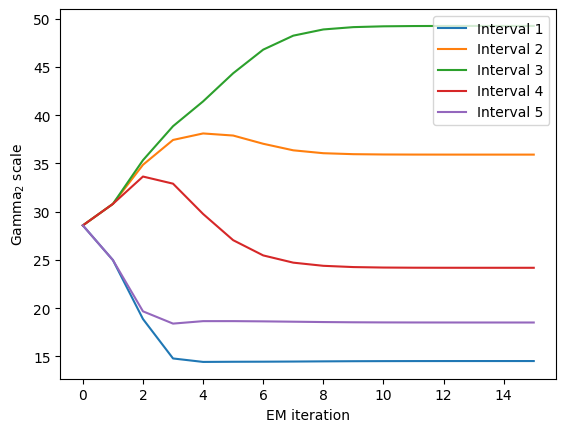

In [31]:
#re-defining the model to remove previous run
lowtol_model = EventModel(n_events=n_events, tolerance=1e-10)
lowtol_loglikelohood, lowtol_estimates = lowtol_model.fit_transform(pattern_data)
plt.plot(lowtol_model.time_pars_dev[:,0,:,1], label=['Interval '+str(x) for x in [1,2,3,4,5]])
plt.ylabel(r'Gamma$_2$ scale')
plt.xlabel('EM iteration')
plt.legend(loc=1)
plt.show()

Here the profile is exactly the same except that the EM algorithm went through a few more iterations.

## Using the single trial estimates

If we select for all trials the most likely sample to contain a transition (e.g. the maximum probability in the single trial plot with p(events) on the y-axis) we can take a look at the recovery of our simulated times on all trials:

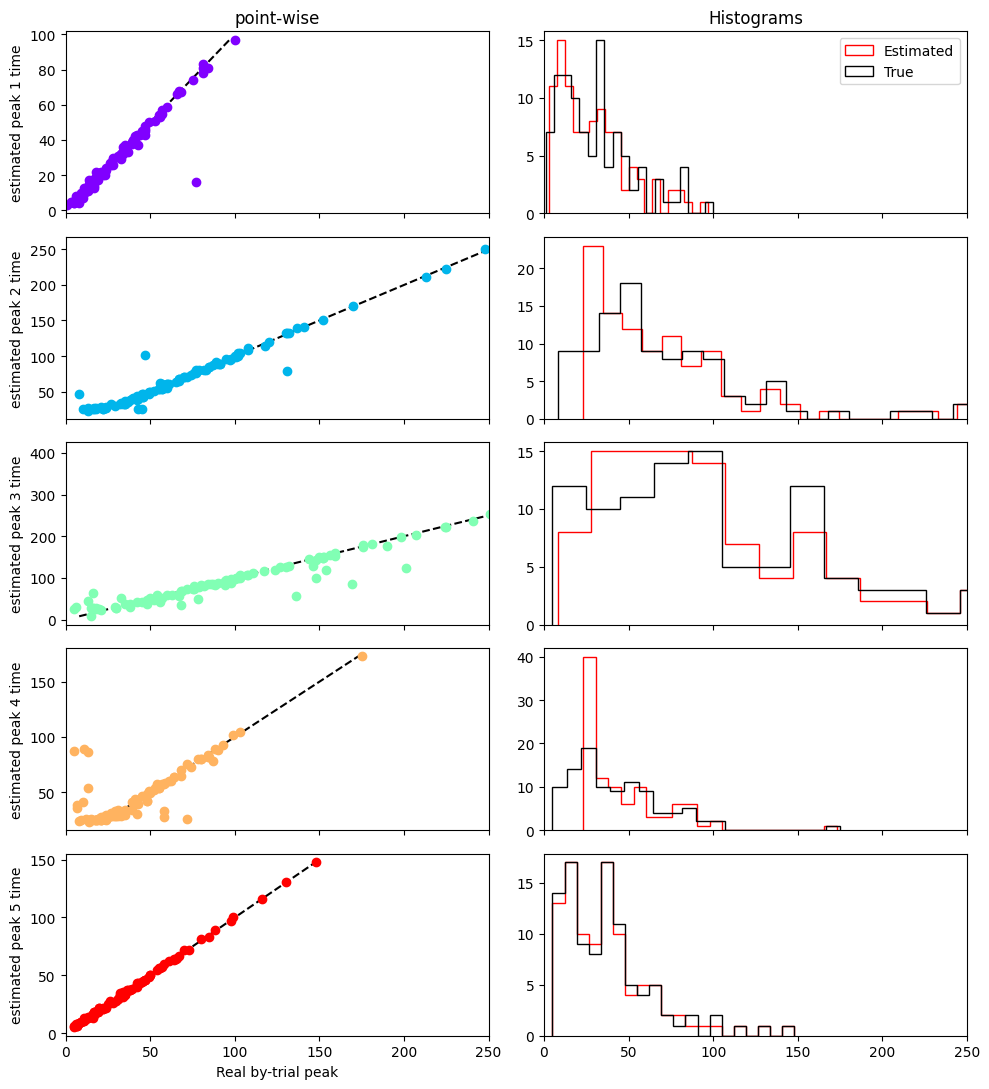

In [32]:
# Estimate the duration between events based on the most time for each event at each trial
estimated_times = hmp.utils.event_times(estimates, duration=True, mean=False, add_rt=True).T

fig, ax = plt.subplots(n_events+1,2, figsize=(10,2.5*n_events+1), dpi=100, sharex=True)
i = 0
ax[0,0].set_title('point-wise')
ax[0,1].set_title('Histograms')
ax[-1,0].set_xlabel('Real by-trial peak')

for event in estimated_times:
    ax[i,0].plot([np.min(event), np.max(event)], [np.min(event), np.max(event)],'--', color='k')
    ax[i,0].plot(sim_source_times[:,i], event, 'o', color=colors[i])
    ax[i,0].set_ylabel(f'estimated peak {i+1} time')
    ax[i,1].hist(event, color='red', bins=20, histtype='step', label='Estimated')
    ax[i,1].hist(sim_source_times[:,i].T, color='k', bins=20, histtype='step', label='True')
    i+= 1
ax[0,-1].legend()
plt.xlim(0,250)
plt.tight_layout()
plt.show()

Overall the exact time of the simulated event is detected as the most likely time by HMP! Of course this will depend on the signal to noise ratio and the non-violation of HMP's assumptions (see the simulations in the [paper](https://direct.mit.edu/imag/article/doi/10.1162/imag_a_00400/125469/Trial-by-trial-detection-of-cognitive-events-in)). It is noteworthy that a few trials are mis-estimated, more on that below.

## A note on minimum distance between events

At model intialization the default behavior of HMP is to assume that successive events are separated by at least the width of an event

In [33]:
model.locations

array([ 0, 50, 50, 50,  0])

This is to prevent events to collapse to the strongest peak in the data. Thus a location is a necessary component of current HMP models (WIP). Nevertheless in some case it might be useful to relax that constraint, for example the trials in the previous time recovery plot shows that trials with short duration between event 3 and 4 (green and orange dashed lines) are mis-estimated and this reflects on the estimation of the other events. This is an example for such a trial:

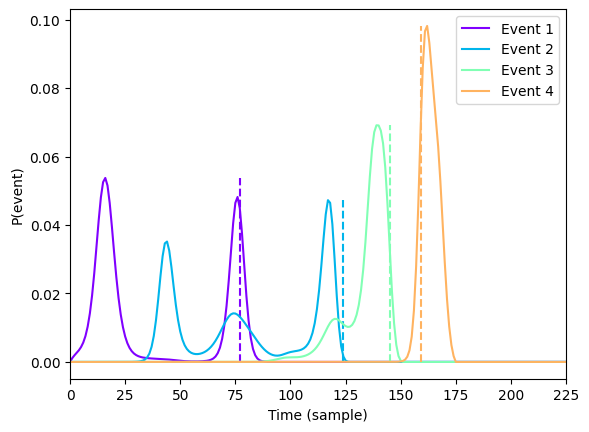

In [34]:
for event in range(n_events):
    plt.plot(estimates.isel(trial=0, event=event), label=f"Event {event+1}",
            color=colors[event])
    plt.vlines(np.sum(sim_source_times[0,:event+1]), 0,
               np.max(estimates.isel(trial=0, event=event)),
              color=colors[event], ls='--')
plt.ylabel('P(event)')
plt.xlabel('Time (sample)')
plt.xlim(0,225)
plt.legend()
plt.show()

Here the blue and orange events cannot be placed at the corresponding correct location (dashed lines) because these times are not possible given the constraint of minimum an event width separating the topographies. 

To recover short durations one solution can be to estimate the model with locations, but turn these off at the moment of the estimation of the probability of the events:

In [35]:
# Turning off the locations from the fitted model
locations = np.repeat(1, n_events+1)
model.locations = locations
# Use the parameters estimated previously and only transform the data with the new locations
_, estimates_overlap = model.transform(pattern_data)

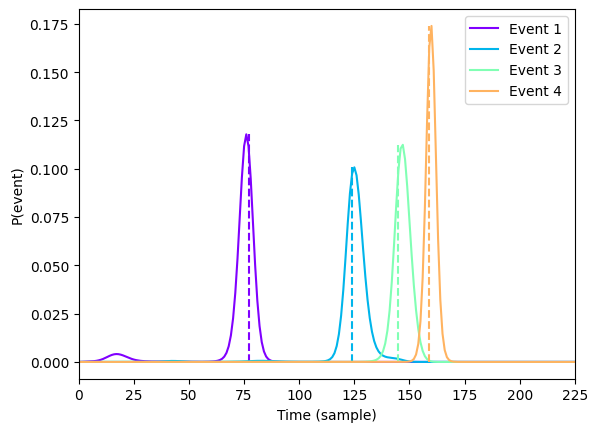

In [36]:
for event in range(n_events):
    plt.plot(estimates_overlap.isel(trial=0, event=event), label=f"Event {event+1}",
            color=colors[event])
    plt.vlines(np.sum(sim_source_times[0,:event+1]), 0,
               np.max(estimates_overlap.isel(trial=0, event=event)),
              color=colors[event], ls='--')
plt.ylabel('P(event)')
plt.xlabel('Time (sample)')
plt.xlim(0,225)
plt.legend()
plt.show()

In this case all works fine, also for the recovery of timing of all trials:

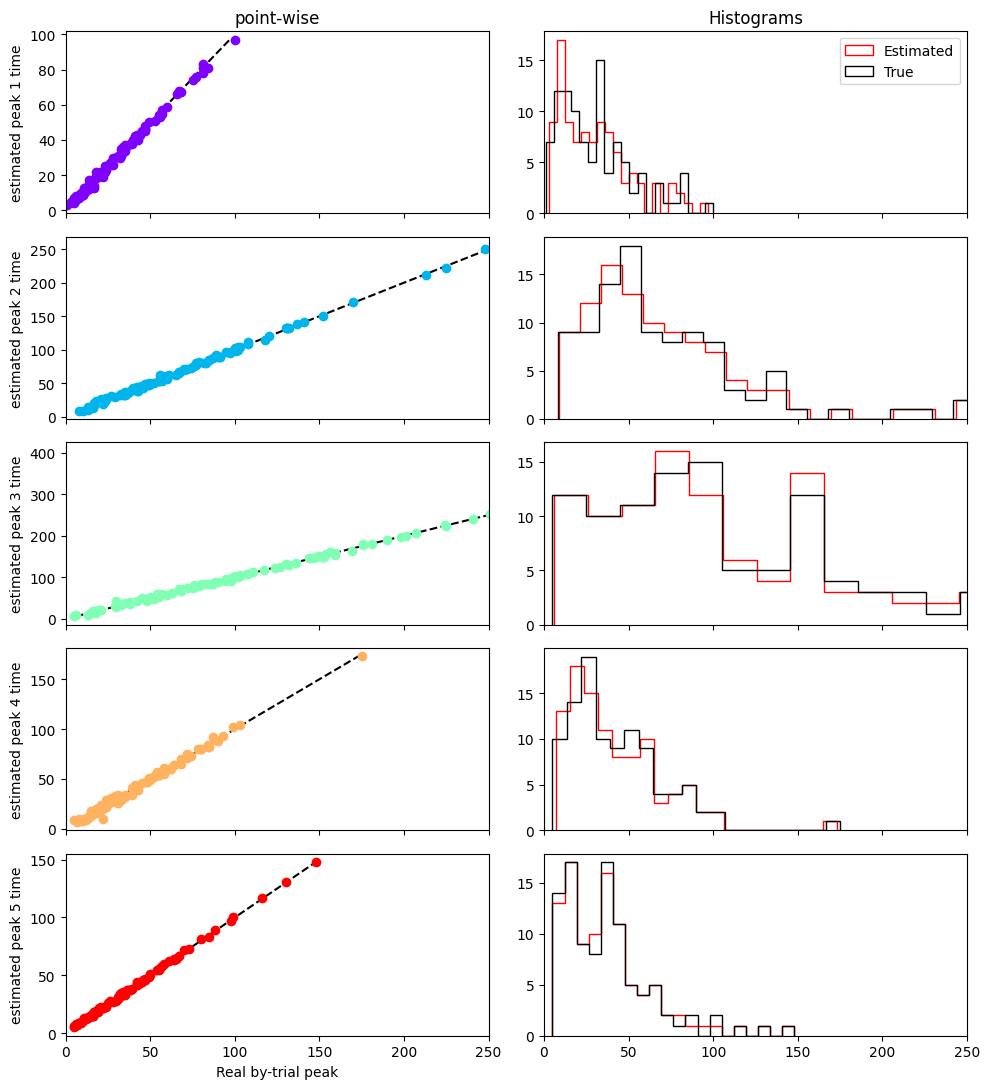

In [37]:
# Estimate the duration between events based on the most time for each event at each trial
estimated_times = hmp.utils.event_times(estimates_overlap, duration=True, mean=False, add_rt=True).T

fig, ax = plt.subplots(n_events+1,2, figsize=(10,2.5*n_events+1), dpi=100, sharex=True)
i = 0
ax[0,0].set_title('point-wise')
ax[0,1].set_title('Histograms')
ax[-1,0].set_xlabel('Real by-trial peak')

for event in estimated_times:
    ax[i,0].plot([np.min(event), np.max(event)], [np.min(event), np.max(event)],'--', color='k')
    ax[i,0].plot(sim_source_times[:,i], event, 'o', color=colors[i])
    ax[i,0].set_ylabel(f'estimated peak {i+1} time')
    ax[i,1].hist(event, color='red', bins=20, histtype='step', label='Estimated')
    ax[i,1].hist(sim_source_times[:,i].T, color='k', bins=20, histtype='step', label='True')
    i+= 1
ax[0,-1].legend()
plt.xlim(0,250)
plt.tight_layout()
plt.show()

**Note:** that this can be used if there is a reason to believe that short durations are present in the data but might not be the best solution in most cases. Additionally the parameters estimated for the topographies will overlap leading to potential mis-estimation.

## Saving and loading a model

Depending on the size of the data (with main factor the sampling rate) the HMP model can take a while to estimate. Therefore, it is often useful to save the model and the estimates for later use. 

In [38]:
import pickle

with open("model.pkl", 'wb') as output:
    pickle.dump(model, output)


# Same goes fpr the estimates
with open("estimates.pkl", 'wb') as output:
    pickle.dump(estimates, output)


For those who are not comfortable in continuing in python you also have the option to just export the estimated event probabilities to a csv for use in other languages/softwares

In [39]:
estimates = estimates.unstack()
estimates.to_dataframe('eventprobs').to_csv('estimates.csv')